> ### 💾 Saving Your Work — Read This First
>
> **Villanova does not use Google Workspace**, so Colab will NOT auto-save to Google Drive unless you sign in with a personal Google account.
> If you close this tab without saving, your work will be lost.
>
> **Two ways to save:**
>
> **Option A — Save to GitHub (recommended):**
> 1. Click **File → Save a copy in GitHub**
> 2. Authorize Colab to access GitHub when prompted (one-time)
> 3. Choose your course repo and click **OK**
> 4. Repeat any time you want to save progress
>
> **Option B — Download to your computer:**
> - Click **File → Download → Download .ipynb**
>
> **Tip:** Save at the end of every section.


# Lab 12: Finding the Weather Radio Gaps

**CSC 2053 — Spring 2026**

---

*NOAA Weather Radio All Hazards (NWR) is the nation's official 24/7 emergency broadcast network — over 1,000 transmitters covering weather alerts, AMBER alerts, and natural disasters across the US.*

*But coverage isn't universal. Today you'll use Pandas, NumPy, Matplotlib, Seaborn, and Folium to map the NWR network and find the cities that fall through the cracks.*

---

**Dataset sources:**
- `wx_stations.csv` — 1,033 US NWR transmitters (FCC/NOAA data via RadioLand)
- `us_cities.csv` — 4,834 US cities with population ≥ 5,000 (contiguous 48 states)

**Lab structure:**
- **Part 1 (Q1–Q6):** Advanced Pandas — profile the NWR network
- **Part 2 (Q7–Q9):** Matplotlib + Seaborn — visualize the data
- **Part 3 (Q10–Q18):** Coverage gap analysis — find underserved cities

**Submission:** Individual work. Submit your completed `.ipynb` via GitHub.


## Setup

Run the cell below to load your libraries and data.

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from IPython.display import display

WX_URL = "https://raw.githubusercontent.com/CSC-2053-Spring-26-100/lab-12-finding-the-weather-radio-gaps/main/wx_stations.csv"
CITIES_URL = "https://raw.githubusercontent.com/CSC-2053-Spring-26-100/lab-12-finding-the-weather-radio-gaps/main/us_cities.csv"

wx = pd.read_csv(WX_URL)

# Longitude is stored as positive in the source data — negate for correct geography
wx['longitude'] = wx['longitude'] * -1

# Filter to US only and drop the 4 rows missing coordinates
wx = wx[wx['country'] == 'USA'].dropna(subset=['latitude', 'longitude']).reset_index(drop=True)

print(f"NWR stations loaded: {len(wx)}")
print(wx.dtypes)


NWR stations loaded: 1029
id                         int64
callsign                  object
frequency                float64
city                      object
state_province            object
country                   object
erp_watts                float64
latitude                 float64
longitude                float64
wfo                       object
transmitter_site          object
hagl                     float64
hagl_source               object
asr_match_distance_km    float64
asr_tower_id             float64
created_at                object
updated_at                object
dtype: object


---
## Part 1: Advanced Pandas

Profile the NWR transmitter network.


### Q1 — Station Counts by State

How many NWR stations does each state have? Print the **top 10 states** by station count.

*Use `value_counts()` on the `state_province` column of `wx`.*


In [2]:
# YOUR CODE HERE
print(wx['state_province'].value_counts().head(10))

state_province
TX    77
AK    52
KY    41
MN    37
MO    35
CA    34
FL    32
MT    31
GA    30
IL    29
Name: count, dtype: int64


---
### New tool: `np.where()`

`np.where(condition, value_if_true, value_if_false)` is a **vectorized if/else** — it applies a condition to every row at once without a Python loop. You can nest calls to handle multiple conditions:

```python
# Example: label rows as 'cheap', 'mid', or 'expensive'
df['price_tier'] = np.where(
    df['price'] < 10, 'cheap',
    np.where(df['price'] < 50, 'mid', 'expensive')
)
```

Think of it as a lookup table built from conditions — fast, readable, and a clean alternative to `.apply()` for simple column assignments.

---

### Q2 — Power Classes

NWR transmitters range from 5-watt gap-fillers to 1,000-watt regional powerhouses.
Add a column called `power_class` to `wx` using `np.where()`:

- `"Low"` — `erp_watts` < 100
- `"Mid"` — `erp_watts` 100–499
- `"High"` — `erp_watts` ≥ 500

The scaffold below handles the nested `np.where()` — fill in the print statement to show the count of each class.


In [4]:
wx['power_class'] = np.where(
    wx['erp_watts'] < 100, 'Low',
    np.where(wx['erp_watts'] < 500, 'Mid', 'High')
)

# YOUR CODE HERE — print the count of each power class
print(wx['power_class'].value_counts())

power_class
Mid     503
High    491
Low      35
Name: count, dtype: int64


---
### New tools: `.dropna()` and `.agg()`

**`.dropna(subset=['col'])`** removes rows where the specified column is missing (`NaN`). Useful before grouping so blank values don't create a spurious extra group:

```python
df.dropna(subset=['owner'])   # removes rows with no owner
```

**`.agg()`** after `.groupby()` lets you compute multiple summary statistics at once and name each result:

```python
df.groupby('band').agg(
    station_count=('callsign', 'count'),
    avg_power=('power', 'mean')
)
```

The syntax is `new_column_name=('source_column', 'function')`. You can mix any combination of `'count'`, `'mean'`, `'sum'`, `'min'`, `'max'`, or even a `lambda`.

---

### Q3 — WFO Coverage Summary

Each NWR transmitter is assigned to a **Weather Forecast Office (WFO)** — the regional NOAA office responsible for that transmitter.

Group `wx` by `wfo` and compute two aggregations. Name your columns exactly as shown (you'll use them in Q8):
- `count` — number of stations per WFO
- `mean_power` — mean `erp_watts` per WFO

Store the result in a variable called `wfo_summary`. Sort by `count` descending and print the top 15.

*Hint: use `.dropna(subset=['wfo'])` before grouping to exclude the 46 stations with no WFO assignment.*


In [6]:
# YOUR CODE HERE
wfo_summary=(
    wx.dropna(subset=['wfo'])
    .groupby('wfo')
    .agg(count=('callsign', 'count'), mean_power=('erp_watts','mean'))
    .reset_index()
    .sort_values('count', ascending=False)
)

print(wfo_summary.head(15).to_string(index=False))

                      wfo  count  mean_power
             Anchorage AK     23  293.478261
               Jackson KY     20  380.000000
        Peachtree City GA     17  664.705882
           Grand Forks ND     16  637.500000
                Juneau AK     16  215.312500
                Duluth MN     15  720.000000
        Salt Lake City UT     15  153.333333
            Des Moines IA     14  450.000000
              Riverton WY     14  400.000000
                Norman OK     13  730.769231
            Binghamton NY     13  550.000000
     Fort Worth-Dallas TX     13  838.461538
Twin Cities-Chanhassen MN     13  786.923077
           Sioux Falls SD     13  730.769231
           Little Rock AR     12  708.333333


---
### New tool: `.query()`

`.query('condition')` filters a DataFrame using a string expression — cleaner than bracket notation for simple conditions:

```python
# These two lines do the same thing:
df[df['power'] >= 50]          # bracket style
df.query('power >= 50')        # query style
```

`.query()` also handles combined conditions neatly:

```python
df.query('band == "FM" and power >= 50')
```

---

### Q4 — High-Power Stations

Use `.query()` to filter `wx` for stations where `erp_watts >= 1000`.

Print the `callsign`, `city`, `state_province`, `erp_watts`, and `wfo` columns for these stations, sorted by power descending.

How many full-power (1,000 W) stations exist?


In [16]:
# YOUR CODE HERE
# YOUR CODE HERE
high_power = wx.query('erp_watts >=1000')
print(f'Full Power Weather Stations: {len(high_power)}')

print(high_power[['callsign', 'city', 'state_province', 'erp_watts', 'wfo']]
      .sort_values('erp_watts', ascending=False))

Full Power Weather Stations: 457
     callsign        city state_province  erp_watts            wfo
1021   WXM-61      LANDER             WY     1000.0    Riverton WY
3     WNG-675      BETHEL             AK     1000.0   Anchorage AK
8      WXJ-79     CORDOVA             AK     1000.0   Anchorage AK
14     WXJ-81   FAIRBANKS             AK     1000.0   Fairbanks AK
15    KPS-503  GLENNALLEN             AK     1000.0   Anchorage AK
...       ...         ...            ...        ...            ...
59     WXL-72   DEMOPOLIS             AL     1000.0  Birmingham AL
57    WNG-646     BREWTON             AL     1000.0      Mobile AL
56     KIH-54  BIRMINGHAM             AL     1000.0  Birmingham AL
55     WWF-54      AUBURN             AL     1000.0  Birmingham AL
53     KIH-58    ANNISTON             AL     1000.0  Birmingham AL

[457 rows x 5 columns]


---
## Part 2: Matplotlib + Seaborn — Class Walkthrough

We'll build these three charts together. Run each cell as we go.

---

### Understanding `fig` and `ax`

Every Matplotlib chart starts with one line:

```python
fig, ax = plt.subplots(figsize=(10, 5))
```

- **`fig`** is the entire figure — the canvas. You rarely touch it directly, but it controls the overall size.
- **`ax`** is the axes — the actual plot area where your data goes. Nearly everything you draw calls a method on `ax`.

This pattern (`fig, ax = plt.subplots()`) is the standard professional way to build charts in Python. It looks verbose at first but gives you precise control, especially when you want multiple plots side by side.

**The general recipe:**
1. `fig, ax = plt.subplots()` — create the canvas
2. `ax.hist(...)` / `ax.scatter(...)` / etc. — draw your data
3. `ax.set_title(...)`, `ax.set_xlabel(...)` — add labels
4. `plt.tight_layout()` then `plt.show()` — render it cleanly


### Q5 — Power Distribution Histogram

A histogram shows the distribution of a numeric column — how many stations fall into each power range.

`ax.axvline()` draws a vertical reference line at any x value, which is useful for marking the mean.


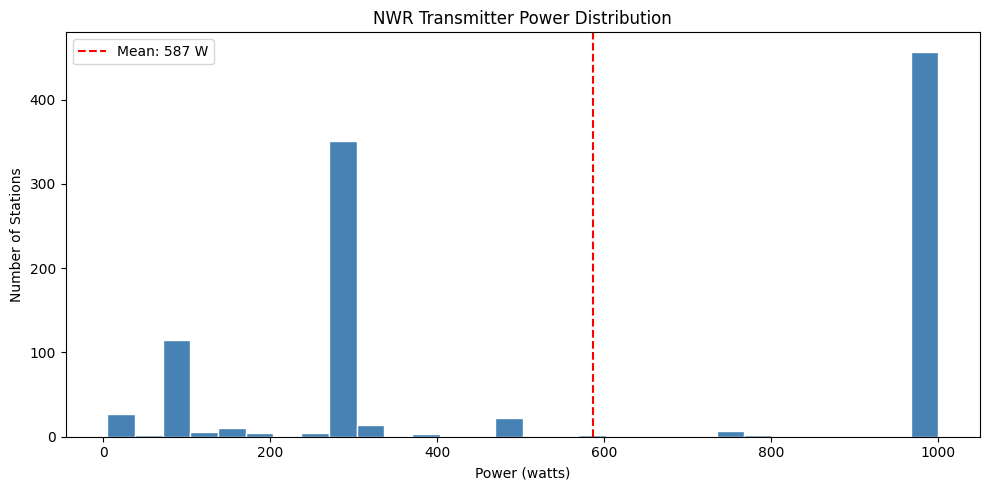

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

mean_power = wx['erp_watts'].mean()

# Draw the histogram — bins=30 divides the range into 30 equal buckets
ax.hist(wx['erp_watts'], bins=30, color='steelblue', edgecolor='white')

# Add a vertical dashed line at the mean
ax.axvline(mean_power, color='red', linestyle='--', label=f'Mean: {mean_power:.0f} W')

ax.set_title("NWR Transmitter Power Distribution")
ax.set_xlabel("Power (watts)")
ax.set_ylabel("Number of Stations")
ax.legend()

plt.tight_layout()
plt.show()


### Q6 — Top WFOs by Station Count (Seaborn)

Seaborn sits on top of Matplotlib — it produces polished charts with less code, but it still uses `fig` and `ax` underneath.

`sns.barplot()` takes a DataFrame and column names directly. We pass `ax=ax` so Seaborn draws into the axes we created, not a new one.

One trick: `sns.barplot()` draws rows **top-to-bottom**, so to get the tallest bar at the top we sort the DataFrame **ascending** first.


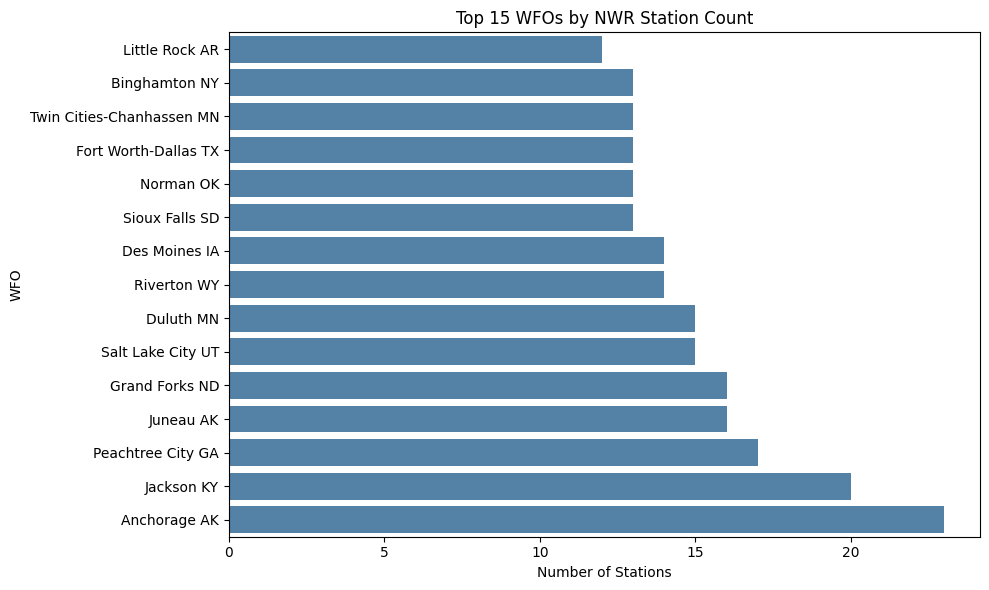

In [18]:
# Sort ascending so the WFO with the most stations ends up at the top of the chart
top15 = wfo_summary.head(15).sort_values('count', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

# Seaborn horizontal bar chart — y is the category, x is the value
sns.barplot(data=top15, y='wfo', x='count', ax=ax, color='steelblue')

ax.set_title("Top 15 WFOs by NWR Station Count")
ax.set_xlabel("Number of Stations")
ax.set_ylabel("WFO")

plt.tight_layout()
plt.show()


### Q7 — Scatter Dot Map

A scatter plot of latitude vs. longitude is a quick way to map geographic data without any special mapping library. We loop over the three power classes and plot each as a separate `ax.scatter()` call so they get different colors and show up individually in the legend.

`alpha=0.6` makes dots slightly transparent so overlapping stations are visible.


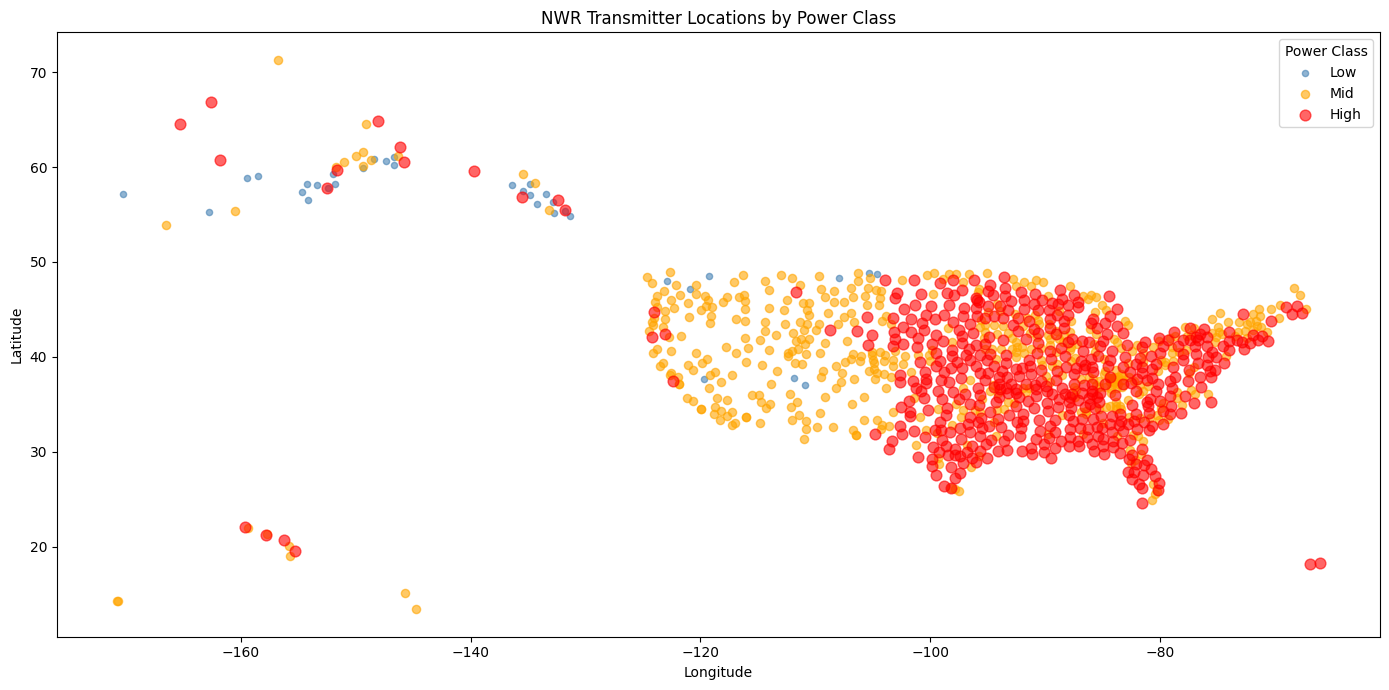

In [19]:
power_styles = {
    'Low':  {'color': 'steelblue', 'size': 20},
    'Mid':  {'color': 'orange',    'size': 35},
    'High': {'color': 'red',       'size': 60},
}

fig, ax = plt.subplots(figsize=(14, 7))

for cls, style in power_styles.items():
    subset = wx[wx['power_class'] == cls]
    ax.scatter(subset['longitude'], subset['latitude'],
               c=style['color'], s=style['size'], label=cls, alpha=0.6)

ax.set_title("NWR Transmitter Locations by Power Class")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title="Power Class")

plt.tight_layout()
plt.show()


---
## Part 3: Coverage Gap Analysis

Now we find the cities that fall through the cracks.

**The question:** For each of the 4,834 US cities with population ≥ 5,000, how far is the nearest NWR transmitter?

A city more than **40 miles** from the nearest station is considered a **gap city** — it may not reliably receive NWR alerts under normal conditions.

> **Why 40 miles?** NWR transmitters have a nominal coverage radius of roughly 40 miles under normal atmospheric conditions. Beyond that, signal quality degrades significantly.


### Q8 — Load City Data

Load `us_cities.csv` into a DataFrame called `cities` using the `CITIES_URL` variable defined in the setup cell.

Print the shape, column names, and first 5 rows.


In [20]:
cities = pd.read_csv(CITIES_URL)

# YOUR CODE HERE — print shape, columns, and head
cities = pd.read_csv(CITIES_URL)
# YOUR CODE HERE — print shape, columns, and head
print(cities.shape)
print(cities.columns.tolist())
print(cities.head())


(4834, 7)
['city', 'state_id', 'state_name', 'county_name', 'lat', 'lng', 'population']
            city state_id  state_name county_name      lat       lng  \
0         Renton       WA  Washington        King  47.4757 -122.1904   
1       Chehalis       WA  Washington       Lewis  46.6649 -122.9660   
2  Mercer Island       WA  Washington        King  47.5624 -122.2265   
3       Lynnwood       WA  Washington   Snohomish  47.8285 -122.3034   
4      Centralia       WA  Washington       Lewis  46.7226 -122.9695   

   population  
0    100953.0  
1      7498.0  
2     25134.0  
3     38092.0  
4     41077.0  


### Q9 — Nearest NWR Station (Vectorized Haversine)

For each city, compute the distance in miles to the **nearest** NWR station.

The `haversine_vec()` function below calculates the distance from **one point** to an **array of points** efficiently using NumPy — no Python loop over stations needed.

**Your job:**
1. Extract the NWR coordinates as NumPy arrays (`wx_lats`, `wx_lons`) — do this **once**, before the loop
2. Loop over each row in `cities` and call `haversine_vec()` with that city's lat/lon and the two arrays
3. Append the **minimum** distance to a list called `nearest`
4. Assign the list to `cities['nearest_nwr_miles']`

*This processes ~4,800 cities × ~1,000 stations. It will take 15–30 seconds — that's normal.*


In [24]:
def haversine_vec(lat1, lon1, lat2_arr, lon2_arr):
    """Vectorized haversine: distance from one point to an array of points (miles)."""
    R = 3958.8
    lat1, lon1 = math.radians(lat1), math.radians(lon1)
    lat2 = np.radians(lat2_arr)
    lon2 = np.radians(lon2_arr)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + math.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))

# Extract NWR coordinates as arrays (do this once, outside the loop)
wx_lats = wx['latitude'].to_numpy()
wx_lons = wx['longitude'].to_numpy()

# YOUR CODE HERE
nearest = []
for _, row in cities.iterrows():
  dists = haversine_vec(row['lat'],row['lng'], wx_lats, wx_lons)
  nearest.append(dists.min())

cities['nearest_nwr_miles'] = nearest

print(cities[['city', 'state_id', 'nearest_nwr_miles']].head())


            city state_id  nearest_nwr_miles
0         Renton       WA           6.048790
1       Chehalis       WA          22.955013
2  Mercer Island       WA           5.648616
3       Lynnwood       WA          21.669201
4      Centralia       WA          19.211520


### Q10 — Average Distance to Nearest NWR

What is the **average** distance (in miles) from a US city to its nearest NWR station?

Print the result rounded to 1 decimal place.


In [25]:
# YOUR CODE HERE
print(round(cities['nearest_nwr_miles'].mean(), 1))


17.6


### Q11 — Percentage of Gap Cities

A **gap city** is one where `nearest_nwr_miles > 40`.

Compute and print:
1. The **number** of gap cities
2. The **percentage** of all cities that are gap cities (round to 1 decimal place)


In [33]:
# YOUR CODE HERE
# YOUR CODE HERE
gap_cities = cities.query('nearest_nwr_miles > 40')

num_gap = len(gap_cities)
pct_gap = round(num_gap / len(cities) * 100, 1)

print(f"Gap cities: {num_gap}")
print(f"Percentage: {pct_gap}%")

Gap cities: 117
Percentage: 2.4%


### Q12 — Top 10 Gap Cities

Print a table of the **10 cities furthest from any NWR station**.

Include these columns: `city`, `state_id`, `county_name`, `population`, `nearest_nwr_miles`

Sort by `nearest_nwr_miles` descending.


In [34]:
# YOUR CODE HERE
print(gap_cities[['city', 'state_id', 'county_name', 'population', 'nearest_nwr_miles']]
      .sort_values('nearest_nwr_miles', ascending=False))


                       city state_id county_name  population  \
3459                Douglas       AZ     Cochise     16885.0   
2382              Dos Palos       CA      Merced      7109.0   
846                 Socorro       NM     Socorro      8554.0   
841   Truth or Consequences       NM      Sierra      7365.0   
2087              Firebaugh       CA      Fresno      8015.0   
...                     ...      ...         ...         ...   
3164             Batesville       IN      Ripley      7922.0   
51                  Connell       WA    Franklin      5243.0   
1571             Sweetwater       TN      Monroe      5589.0   
2483         Pagosa Springs       CO   Archuleta      5225.0   
4738            Morganfield       KY       Union      5618.0   

      nearest_nwr_miles  
3459          83.411605  
2382          70.696618  
846           70.190155  
841           69.751328  
2087          65.277155  
...                 ...  
3164          40.370485  
51            40.198060

### Q13 — State with the Most Gap Cities

Which state has the most cities that are gap cities (more than 40 miles from any NWR station)?

Print the **top 10 states** by gap city count.

*Hint: filter `cities` to gap cities first, then use `value_counts()` on `state_id`.*


In [35]:
# YOUR CODE HERE
# YOUR CODE HERE
gap_by_state = gap_cities['state_id'].value_counts()
print(gap_by_state.head(10))


state_id
CA    55
AZ     9
TX     8
WA     5
NM     5
CO     5
TN     4
LA     4
UT     4
OH     2
Name: count, dtype: int64


### Q14 — Load Tornado Data

The NOAA Storm Prediction Center maintains a record of every confirmed US tornado since 1950.

Load the CSV below into a DataFrame called `tornadoes`, then filter it down to the storms that matter most for NWR:

- Keep only rows where `mag >= 3` (F3/EF3 and above — winds 136+ mph, capable of destroying well-built homes)
- Drop rows where `mag == -9` (unknown/unrated events — treat these as missing data)
- Drop rows where `st` is in `['AK', 'HI', 'PR', 'VI']` to stay within the contiguous 48 states

Print the total count of qualifying tornadoes and the top 10 states by count.

> **F vs EF scale:** The SPC switched from the Fujita (F) scale to the Enhanced Fujita (EF) scale in 2007.
> This dataset uses the same `mag` column (0–5) for both eras, so `mag >= 3` captures F3+ (pre-2007)
> and EF3+ (2007–present) without any extra handling.


In [37]:
TORNADO_URL = "https://www.spc.noaa.gov/wcm/data/1950-2024_actual_tornadoes.csv"

tornadoes = pd.read_csv(TORNADO_URL)

tornadoes = tornadoes[(tornadoes['mag']>=3) &
 (tornadoes['mag'] !=-9) &
  (~tornadoes['st'].isin(['AK','HI','PR','VI'])
  )].reset_index(drop=True)

# YOUR CODE HERE — filter to mag >= 3, drop mag == -9, drop non-contiguous states
# Store the filtered result back in tornadoes

# Print total count and top 10 states by F3+/EF3+ count
print(tornadoes['st'].value_counts().head(10))

st
TX    398
OK    265
KS    234
MS    190
AL    184
AR    178
IA    167
IL    140
MO    139
NE    130
Name: count, dtype: int64


### Q15 — Tornado Risk in Gap States

Do the states with the most NWR coverage gaps also face the most tornado risk?

The code below compares your top 5 gap states against the F3+/EF3+ tornado record.

**You may need to update the variable names** on the first two lines to match what you called things in Q13 and Q14:
- `gap_by_state` — your Series of gap city counts per state from Q13
- `tornadoes` — your filtered tornado DataFrame from Q14


In [ ]:
# Update these variable names if yours are different
gap_counts     = gap_by_state          # Series: state → gap city count (from Q13)
tornado_counts = tornadoes['st'].value_counts()   # Series: state → F3+/EF3+ count

top5_states = gap_counts.head(5).index.tolist()

print(f"{'State':<8} {'Gap Cities':>12} {'F3+/EF3+ Tornadoes':>20}")
print("-" * 42)
for st in top5_states:
    print(f"{st:<8} {gap_counts.get(st, 0):>12} {tornado_counts.get(st, 0):>20}")


### Q16 — Written Response

In 3–4 sentences: **Which regions of the US have the worst NWR coverage gaps, and does the tornado data make those gaps more alarming?**

Use specific numbers from Q11–Q15 in your answer.

*Double-click this cell to edit it and write your answer below.*

---

**Your answer:** *(write here)*


### Q17 — Folium Map: NWR Coverage + Tornado Risk

The starter code creates the map, plots all NWR stations as blue markers, and handles the legend.

**Your job — add two layers:**

1. **Red markers** for every gap city (`nearest_nwr_miles > 40`):
   - `radius=4`, `color='red'`, `fill=True`, `fill_opacity=0.6`
   - Popup: `"{city}, {state_id} — {nearest_nwr_miles:.1f} mi from nearest NWR"`

2. **Orange markers** for every tornado in `tornadoes` (use `slat`/`slon` for the start location):
   - `radius=2`, `color='orange'`, `fill=True`, `fill_opacity=0.3`
   - Popup: `"F/EF{mag} — {st}, {yr}"`

*Display the map with `display(m)` at the end.*


In [ ]:
m = folium.Map(location=[39.5, -98.35], zoom_start=4, tiles='CartoDB positron')

# NWR stations — blue markers (provided)
for _, row in wx.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color='steelblue',
        fill=True,
        fill_opacity=0.5,
        popup=f"{row['callsign']} ({row['erp_watts']} W) — {row['city']}, {row['state_province']}"
    ).add_to(m)

# YOUR CODE HERE — add red gap city markers

# YOUR CODE HERE — add orange F3+/EF3+ tornado markers

# Legend (provided)
legend_html = (
    '<div style="position: fixed; bottom: 30px; right: 30px; z-index: 1000; '
    'background-color: white; padding: 10px 14px; border: 2px solid grey; '
    'border-radius: 5px; font-size: 13px; line-height: 1.8;">'
    '<b>Legend</b><br>'
    '<span style="color: steelblue; font-size: 16px;">&#9679;</span> NWR Transmitter<br>'
    '<span style="color: red; font-size: 16px;">&#9679;</span> Gap City (&gt;40 mi)<br>'
    '<span style="color: orange; font-size: 16px;">&#9679;</span> F3+/EF3+ Tornado (1950–2024)<br>'
    '</div>'
)
m.get_root().html.add_child(folium.Element(legend_html))

display(m)


### Q18 — Written Response: Policy Recommendation

Based on everything you've found, write **one concrete policy recommendation** for NOAA or the FCC.

Where should the next NWR transmitter be built, and why? Use specific data from Q10–Q15 — gap city counts, distances, and tornado history — to make your case.

*Double-click this cell to edit it and write your answer below.*

---

**Your recommendation:** *(write here)*
